In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
transactions=pd.read_csv("C:\\Data Analytics\\archive\\Financial Fraud Dataset\\Transaction_Data_250k.csv")
transactions['Transaction_Date']=pd.to_datetime(transactions['Transaction_Date'])
transactions['Transaction_year']=transactions['Transaction_Date'].dt.year
transactions.head(5)

,Transaction_ID,Customer_ID,Card_ID,Merchant_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,...,Is_International,Fraud_Flag,Fraud_Reason,Merchant_Risk_Level,Merchant_Category,Customer_State,Customer_City,Merchant_State,Merchant_City,Transaction_year
0,TXN1000001,CUST100660,CARD500875,MER100380,2024-03-03,05:50:10,21748.02,Debit Card,Mobile App,Android Mobile,...,1,0,NaN,Low,Hotel,Tamil Nadu,Madurai,Tamil Nadu,Salem,2024
1,TXN1000002,CUST111388,CARD514772,MER100017,2023-11-08,06:55:15,9960.60,Debit Card,POS,POS Terminal,...,0,0,NaN,Low,Travel,Kerala,Kollam,Haryana,Nuh,2023
2,TXN1000003,CUST115872,CARD520625,MER100143,2023-01-11,02:17:28,838.61,Debit Card,ATM,ATM Machine,...,0,0,NaN,Low,Food Delivery,Uttar Pradesh,Agra,West Bengal,Kolkata,2023
3,TXN1000004,CUST109049,CARD511773,MER100053,2023-05-25,01:48:56,52694.99,Credit Card,POS,POS Terminal,...,0,0,NaN,Low,Financial Services,Punjab,Ludhiana,Madhya Pradesh,Indore,2023
4,TXN1000005,CUST114459,CARD518771,MER100064,2023-10-22,00:23:32,1043.40,Debit Card,Online Web,Android Mobile,...,0,0,NaN,Low,Entertainment,Maharashtra,Thane,Madhya Pradesh,Jabalpur,2023


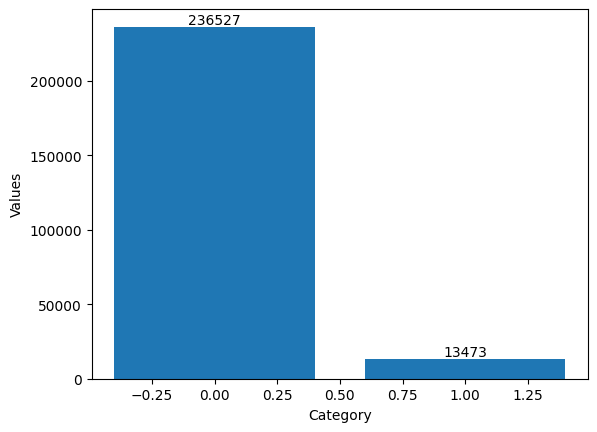

In [3]:
counts=transactions['Fraud_Flag'].value_counts()
bars=plt.bar(counts.index,counts.values)
plt.xlabel("Category")
plt.ylabel("Values")
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height,str(height),ha='center',va='bottom')
plt.show()

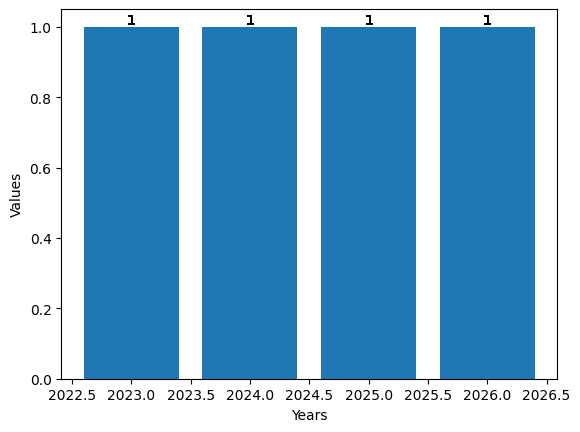

In [4]:
trans_fraud=transactions.groupby(['Transaction_year','Fraud_Flag']).value_counts().reset_index(name='count')
bars1=plt.bar(trans_fraud['Transaction_year'],trans_fraud['Fraud_Flag'])
plt.xlabel("Years")
plt.ylabel("Values")
for bar in bars1:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height,str(height),ha='center',va='bottom')
plt.show()

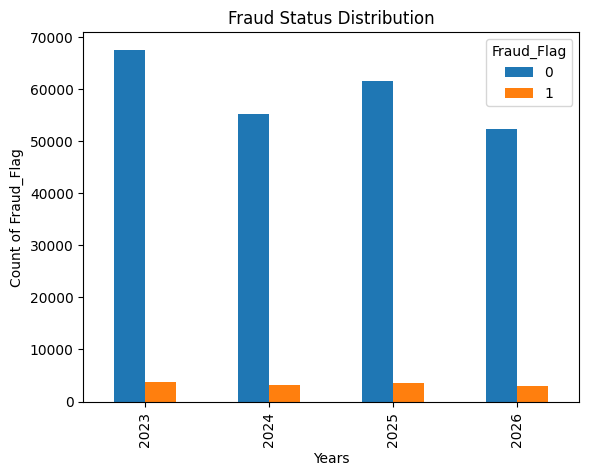

In [5]:
trans_fraud=transactions.groupby(['Transaction_year','Fraud_Flag']).size().reset_index(name='Fraud_Status')
pivot_df=trans_fraud.pivot(index='Transaction_year',columns='Fraud_Flag',values='Fraud_Status').fillna(0)
pivot_df.plot(kind='bar')
plt.xlabel("Years")
plt.ylabel("Count of Fraud_Flag")
plt.title("Fraud Status Distribution")
plt.show()

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.metrics import accuracy_score
le=LabelEncoder()
df=pd.read_excel("C:\\Data Analytics\\archive\\Financial Fraud Dataset\\Transactions_Cleaned.xlsx")
#df.head()

,Transaction_ID,Customer_ID,Card_ID,Merchant_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,...,Is_International,Fraud_Flag,Fraud_Reason,Merchant_Risk_Level,Merchant_Category,Customer_State,Customer_City,Merchant_State,Merchant_City,International_or_Domestic
0,TXN1000001,CUST100660,CARD500875,MER100380,2024-03-03,05:50:10,21748.019531,Debit Card,Mobile App,Android Mobile,...,1,0,NaN,Low,Hotel,Tamil Nadu,Madurai,Tamil Nadu,Salem,Domestic
1,TXN1000002,CUST111388,CARD514772,MER100017,2023-11-08,06:55:15,9960.599609,Debit Card,POS,POS Terminal,...,0,0,NaN,Low,Travel,Kerala,Kollam,Haryana,Nuh,Domestic
2,TXN1000003,CUST115872,CARD520625,MER100143,2023-01-11,02:17:28,838.609985,Debit Card,ATM,ATM Machine,...,0,0,NaN,Low,Food Delivery,Uttar Pradesh,Agra,West Bengal,Kolkata,Domestic
3,TXN1000004,CUST109049,CARD511773,MER100053,2023-05-25,01:48:56,52694.988281,Credit Card,POS,POS Terminal,...,0,0,NaN,Low,Financial Services,Punjab,Ludhiana,Madhya Pradesh,Indore,Domestic
4,TXN1000005,CUST114459,CARD518771,MER100064,2023-10-22,00:23:32,1043.400024,Debit Card,Online Web,Android Mobile,...,0,0,NaN,Low,Entertainment,Maharashtra,Thane,Madhya Pradesh,Jabalpur,Domestic


In [10]:
categorical_cols=['Payment_Method','Transaction_Channel','Device_Type','Transaction_Status','International_or_Domestic','Merchant_Risk_Level']
df_encoded=pd.get_dummies(df[categorical_cols],drop_first=True)
X=df_encoded
y=df['Fraud_Flag']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
model=LogisticRegression()
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=skf,scoring='accuracy')
print(scores.mean())
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy Score:",accuracy_score(y_pred,y_test))
train_acc=model.score(X_train,y_train)
test_acc=model.score(X_test,y_test)
print("Train Score:",train_acc)
print("Test Score:",test_acc)

0.9550599999999999
Accuracy Score: 0.95546
Train Score: 0.95496
Test Score: 0.95546
